# NB03 — Bradley-Terry Model

**Input:**
- `data/processed/comparisons.csv` — paarsgewijze vergelijkingen (winner/loser)
- `data/processed/intersection_index.csv` — kruispunt-ID <-> integer index

**Output:** `data/processed/bt_params.csv` — ruwe log-sterkte parameter per kruispunt

**Doel:** Schat een Bradley-Terry model met de `choix` library. Elk kruispunt krijgt een
log-sterkte parameter: hoe hoger, hoe vaker het kruispunt als gevaarlijker werd beoordeeld.
Twee schatters worden vergeleken:
- `ilsr_pairwise` — Iterative Luce Spectral Ranking (standaard; snellere convergentie op sparse graphs)
- `opt_pairwise` — Maximum likelihood optimalisatie (referentie)

**Vereist:** `pip install choix`

## Stap 1 — Data laden en integer-indices voorbereiden

`choix` verwacht vergelijkingen als een lijst van `(winner_idx, loser_idx)` tuples, waarbij
de indices integers zijn van 0 t/m n-1. We laden de vaste index-volgorde uit NB02 zodat
de mapping tussen kruispunt-ID en integer consistent blijft.

In [3]:
import pandas as pd
import numpy as np
import choix
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
PROC_DIR = BASE_DIR / "data" / "processed"

comparisons_df = pd.read_csv(PROC_DIR / "comparisons.csv", dtype={"winner": str, "loser": str})
index_df       = pd.read_csv(PROC_DIR / "intersection_index.csv", dtype={"intersection_id": str})

# Bouw mapping: kruispunt-ID -> integer index (vereist door choix)
id_to_idx = dict(zip(index_df["intersection_id"], index_df["index"]))
n_items   = len(index_df)

print(f"Vergelijkingen: {len(comparisons_df)}")
print(f"Items (kruispunten): {n_items}")

Vergelijkingen: 216
Items (kruispunten): 68


## Stap 2 — Vergelijkingen omzetten naar (winner_idx, loser_idx) tuples

`choix` verwerkt geen string-ID's maar integer-indices. We converteren elke vergelijking
naar een tuple van twee integers op basis van de index-tabel uit NB02.

In [4]:
data = [
    (id_to_idx[row["winner"]], id_to_idx[row["loser"]])
    for _, row in comparisons_df.iterrows()
]

print(f"Vergelijkings-tuples gebouwd: {len(data)}")
print(f"Voorbeelden: {data[:3]}")

Vergelijkings-tuples gebouwd: 216
Voorbeelden: [(38, 15), (64, 30), (16, 9)]


## Stap 3 — Bradley-Terry schatten: ILSR (primaire schatter)

ILSR (Iterative Luce Spectral Ranking) convergeert sneller dan pure MLE op sparse graphs
en is daarmee de aanbevolen schatter voor dit dataset. De `alpha`-parameter is een L2-regularisatie:
hij voorkomt degenererende scores voor kruispunten met zeer weinig vergelijkingen.

In [5]:
# alpha=0.01 zorgt voor lichte regularisatie; verhoog bij problemen met convergentie
params_ilsr = choix.ilsr_pairwise(n_items, data, alpha=0.01)

print("ILSR parameters (log-sterkte):")
print(f"  min:        {params_ilsr.min():.4f}")
print(f"  max:        {params_ilsr.max():.4f}")
print(f"  gemiddelde: {params_ilsr.mean():.4f}")
print(f"  std:        {params_ilsr.std():.4f}")

ILSR parameters (log-sterkte):
  min:        -2.7040
  max:        1.8836
  gemiddelde: -0.0000
  std:        0.9742


## Stap 4 — Bradley-Terry schatten: MLE-optimalisatie (referentie)

De MLE-schatter (`opt_pairwise`) maximaliseert de log-likelihood direct via gradient descent.
We vergelijken de uitkomst met ILSR: als de Pearson-correlatie hoog is (>0.99) zijn de twee
methoden in de praktijk uitwisselbaar op dit dataset.

In [6]:
params_opt = choix.opt_pairwise(n_items, data, alpha=0.01)

print("OPT parameters (log-sterkte):")
print(f"  min:        {params_opt.min():.4f}")
print(f"  max:        {params_opt.max():.4f}")
print(f"  gemiddelde: {params_opt.mean():.4f}")
print(f"  std:        {params_opt.std():.4f}")

# Pearson-correlatie tussen de twee schatters
corr = np.corrcoef(params_ilsr, params_opt)[0, 1]
print(f"\nCorrelatie ILSR vs OPT: {corr:.4f}")

OPT parameters (log-sterkte):
  min:        -5.9698
  max:        4.6976
  gemiddelde: 0.0000
  std:        2.4194

Correlatie ILSR vs OPT: 0.9160


## Stap 5 — Visuele vergelijking van de twee schatters

Een scatter (ILSR vs OPT) laat zien of de twee methoden tot dezelfde rangorde komen.
Het histogram van ILSR-parameters geeft een indruk van de spreiding in gepercipieerde
gevaarlijkheid over de kruispunten.

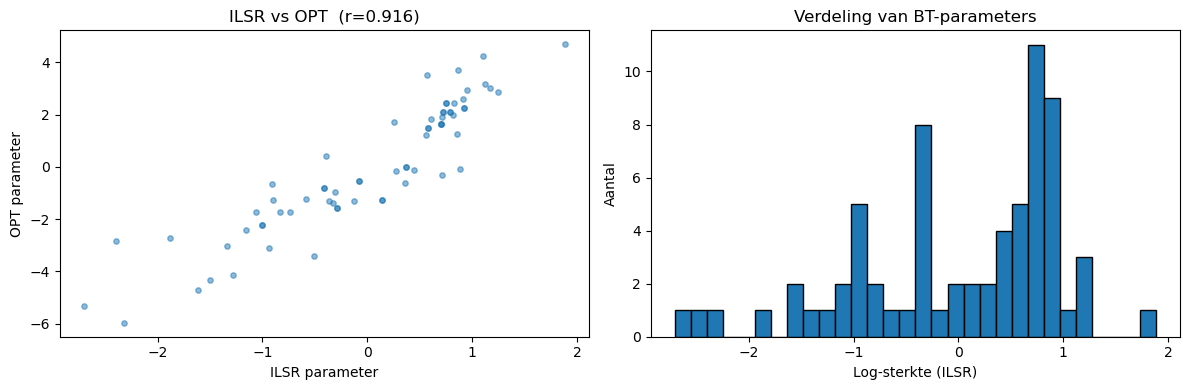

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(params_ilsr, params_opt, alpha=0.5, s=15)
axes[0].set_xlabel("ILSR parameter")
axes[0].set_ylabel("OPT parameter")
axes[0].set_title(f"ILSR vs OPT  (r={corr:.3f})")

axes[1].hist(params_ilsr, bins=30, edgecolor="black")
axes[1].set_xlabel("Log-sterkte (ILSR)")
axes[1].set_ylabel("Aantal")
axes[1].set_title("Verdeling van BT-parameters")

plt.tight_layout()
plt.savefig(PROC_DIR / "bt_parameter_comparison.png", dpi=120)
plt.show()

## Stap 6 — Opslaan

Sla beide parametersets op. ILSR is de primaire schatter die in NB04 en NB05 wordt gebruikt.
De OPT-kolom staat er als referentie bij.

In [8]:
bt_params_df = index_df.copy()
bt_params_df["bt_param_ilsr"] = params_ilsr
bt_params_df["bt_param_opt"]  = params_opt

out_path = PROC_DIR / "bt_params.csv"
bt_params_df.to_csv(out_path, index=False)

print(f"Opgeslagen: {len(bt_params_df)} rijen -> {out_path.resolve()}")
bt_params_df.sort_values("bt_param_ilsr", ascending=False).head(10)

Opgeslagen: 68 rijen -> C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\bradley_terry\data\processed\bt_params.csv


,intersection_id,index,bt_param_ilsr,bt_param_opt
66,600483010,66,1.883625,4.697614
67,600488624,67,1.250651,2.880131
58,191269022,58,1.165261,3.024608
51,188278029,51,1.125546,3.158864
61,192266023,61,1.099864,4.261665
62,194264006,62,0.953093,2.946893
39,186275043,39,0.924628,2.240236
41,186279088,41,0.924628,2.240236
38,186275023,38,0.909198,2.614123
57,190273120,57,0.884923,-0.091956
